In [9]:
%pip install numpy
%pip install scipy
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn

/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


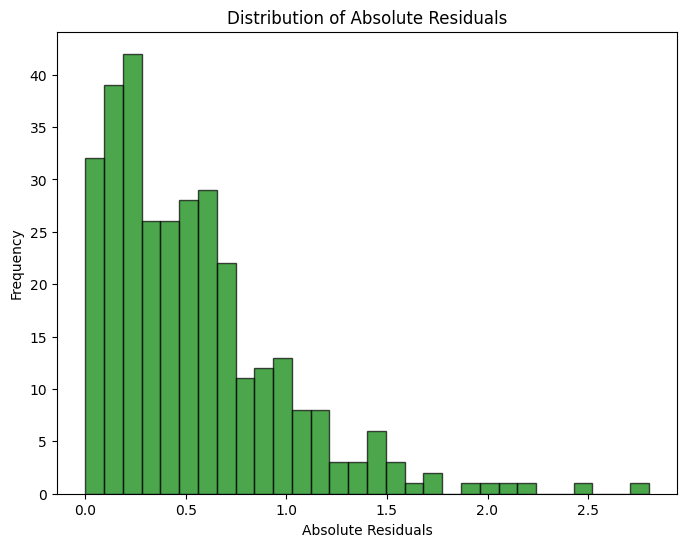

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

data = pd.read_csv('winequality-red.csv', sep=';')

# Assign appropriate column names (added manually do to a recurrent error)

column_names = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", 
                "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", 
                "pH", "sulphates", "alcohol", "quality"]

data.columns = column_names

# 'quality' is the target variable
X = data.drop('quality', axis=1)  
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# MLP regressor
mlp = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', early_stopping=True, validation_fraction=0.2, random_state=0)
mlp.fit(X_train, y_train)

# Predict using the MLP regressor
y_pred = mlp.predict(X_test)

# Calculate the residuals
residuals = y_test - y_pred

# Absolute values of the residuals
absolute_residuals = abs(residuals)


plt.figure(figsize=(8, 6))
plt.hist(absolute_residuals, bins=30, edgecolor='k', alpha=0.7, color='green')
plt.title('Distribution of Absolute Residuals')
plt.xlabel('Absolute Residuals')
plt.ylabel('Frequency')
plt.show()

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

# MLP Without Rounding and Bounding
y_pred_no_round = mlp.predict(X_test)

# Calculate MAE Without Rounding and Bounding
mae_no_round = mean_absolute_error(y_test, y_pred_no_round)
print(f"MAE without rounding and bounding: {mae_no_round}")

# Rounding and Bounding the Predictions
y_pred_rounded = y_pred_no_round.round().clip(min=0, max=10)  # Assuming quality ranges from 0 to 10

# Calculate MAE After Rounding and Bounding
mae_rounded = mean_absolute_error(y_test, y_pred_rounded)
print(f"MAE after rounding and bounding: {mae_rounded}") 


'''
The small decrease in the value of the MAE indicates that the rounded and bounded predictions were closer to the actual values compared to the
unrounded predictions, since it reduced the average absolute error between the predicted and actual values. Therefore, we can assume that
rounding and bounding the predictions had a positive impact on the MLP learnt in previous question.
'''



MAE without rounding and bounding: 0.49426521845062704
MAE after rounding and bounding: 0.428125


'\nThe small decrease in the value of the MAE indicates that the rounded and bounded predictions were closer to the actual values compared to the\nunrounded predictions, since it reduced the average absolute error between the predicted and actual values. Therefore, we can assume that\nrounding and bounding the predictions had a positive impact on the MLP learnt in previous question.\n'

/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


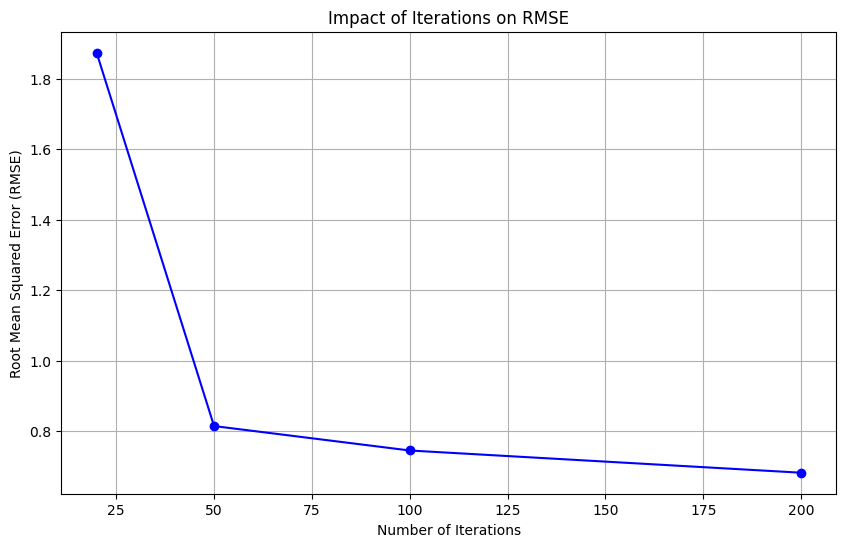

"\nThe graph shows that the RMSE decreases as the number of iterations increases, however, there is a point where the RMSE starts to plateau, which means that increasing the number \nof iterations does not significantly improve the model's performance, and, consequently, that the model may be overfitting.\n"

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

num_iterations = [20, 50, 100, 200]
rmse_values = []

# Loop through the different numbers of iterations
for iterations in num_iterations:
    # Train the MLP with a fixed number of iterations
    mlp_fixed_iterations = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', max_iter=iterations, random_state=0)
    mlp_fixed_iterations.fit(X_train, y_train)
    
    # Make predictions
    y_pred_fixed_iterations = mlp_fixed_iterations.predict(X_test)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_fixed_iterations))
    
    # Append RMSE value to the list
    rmse_values.append(rmse)


plt.figure(figsize=(10, 6))
plt.plot(num_iterations, rmse_values, marker='o', color='blue')
plt.xlabel('Number of Iterations')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Impact of Iterations on RMSE')
plt.grid(True)
plt.show()

'''
The graph shows that the RMSE decreases as the number of iterations increases, however, there is a point where the RMSE starts to plateau, which means that increasing the number 
of iterations does not significantly improve the model's performance, and, consequently, that the model may be overfitting.
'''


In [55]:
'''
The graph shows that the RMSE decreases as the number of iterations increases, due to the fact that each iteration allows the model to learn more about the data and improve 
its predictions. However, at around the 100th iteration, the RMSE starts to plateau, which can suggest that it is around this iteration that the model converges on a good solution, 
and, from this point onwards, it could be overfitting. Therefore, since the model seems to reach a point where it has converged on a good solution,
we can conclude that replacing early stopping by a well-defined number of iterations has a positive impact on RMSE.

So, in this scenario, early stopping is worsening the performance by helping to prevent overfitting, because the model is underfitting the training data and is not able to
learn the underlying patterns in the training data, preventing it from learning enough to make accurate predicitions. However, the fact that early stopping prevents overfitting
can also be a powerful advantage, since it can help to improve the performance of machine learning models, saving computational resources, and preventing the model from 
learning noise in the training data.


'''

'\nThe graph shows that the RMSE decreases as the number of iterations increases, due to the fact that each iteration allows the model to learn more about the data and improve \nits predictions. However, at around the 100th iteration, the RMSE starts to plateau, which can suggest that it is around this iteration that the model converges on a good solution, \nand, from this point onwards, it could be overfitting. Therefore, since the model seems to reach a point where it has converged on a good solution,\nwe can conclude that replacing early stopping by a well-defined number of iterations has a positive impact on RMSE.\n\nSo, in this scenario, early stopping is worsening the performance by helping to prevent overfitting, because the model is underfitting the training data and is not able to\nlearn the underlying patterns in the training data, preventing it from learning enough to make accurate predicitions. However, the fact that early stopping prevents overfitting\ncan also be a powerf